In [1]:
import yaml

model_cfg = "unet.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'unet'

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann:
                continue

            rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
            mask = coco_mask.decode(rles)
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

            # ⚠️ Filter out zero-area boxes *after transforms*
            boxes = target["boxes"]
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])

            # Apply keep mask to all fields
            target["boxes"] = tv_tensors.BoundingBoxes(boxes[keep], format="XYXY", canvas_size=img.shape[-2:])
            target["labels"] = target["labels"][keep]
            if "masks" in target:
                target["masks"] = target["masks"][keep]
            if "area" in target:
                target["area"] = target["area"][keep]
            if "iscrowd" in target:
                target["iscrowd"] = target["iscrowd"][keep]

        return img, target

    def __len__(self):
        return len(self.ids)


In [3]:
from torchvision.transforms import v2 as T
import torch

def get_transform(train: bool):
    if train:
        transforms = [
            T.RandomPhotometricDistort(),  # Color jitter
            T.Resize((512, 512)),          # Fixed resize for stability
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10, fill=0, expand=False),  # Limit rotation area
            # T.RandomZoomOut(fill=0, p=0.3),  # Optional — leave off for now
            # T.RandomCrop((512, 512), pad_if_needed=False, fill=0),  # Only if images are bigger
        ]
    else:
        transforms = [
            T.Resize((512, 512)),                                   # Consistent resize for val/test
        ]

    transforms += [
        T.ToDtype(torch.float32, scale=True),                       # Convert image to float32 in [0, 1]
        T.ToPureTensor(),                                           # Convert to torch.Tensor (Image, Mask, BBoxes)
    ]

    return T.Compose(transforms)

In [4]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate

from tqdm import tqdm
import sys
import time

from models import MODEL_REGISTRY



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# COCO-style dataset using your structure
dataset = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/train",
    transforms=get_transform(train=True)
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/valid",
    transforms=get_transform(train=False)
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/test",
    transforms=get_transform(train=False)
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dynamically assign number of workers
n_workers = 4 if torch.cuda.is_available() else 0

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers = n_workers,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

# Two classes: background + foreground
num_classes = cfg['num_classes']

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
#model = get_model_instance_segmentation(num_classes)

model.to(device)

loading annotations into memory...
Done (t=0.29s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Train size: 1049
Validation size: 300
Test size: 150


UNetWithLoss(
  (model): UNet(
    (enc1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 64, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (enc2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 128, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (enc3): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 256, eps=1e-05, affi

In [5]:
# Model
model_name = "unet_20250621_2130"

# Load weights with correct device mapping
model.load_state_dict(torch.load(
    f"outputs/{model_name}/model_best.pth",
    map_location=device  # Automatically maps to CPU or CUDA as available
))

# Move model to device
model.to(device)

UNetWithLoss(
  (model): UNet(
    (enc1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 64, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (enc2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 128, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (enc3): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 256, eps=1e-05, affi

{'masks': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), 'scores': tensor([1.]), 'labels': tensor([1])}


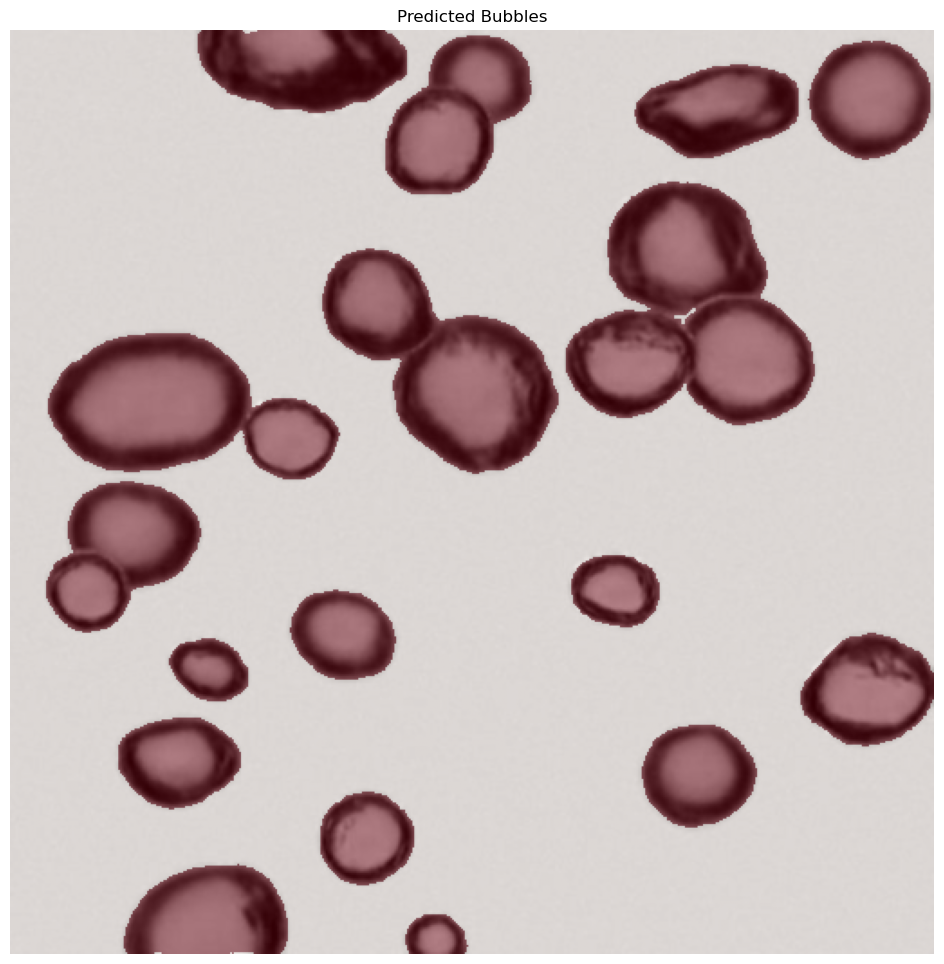

In [6]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

score_thresh = 0
min_area = 0

eval_transform = get_transform(train=False)
image = read_image("../../../BubANN_GAN.v1i.coco-segmentation/test/BubGAN_0002_jpg.rf.a78f79c439aaf0c4cfcaac4ce751a071.jpg")
#image = read_image("../../../datasets/frames_ana/02_07_20/qc2_qd1_10x_formacao2/qc2_qd1_10x_formacao2_00000.jpg")
#image = read_image("../../../datasets/chosen_images/10x_qc1_qd2_2_00000.jpg")

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to(device)

    predictions = model([x])
    pred = predictions[0]

print(pred)


# Filter by score
scores = pred["scores"].cpu()
keep = scores > score_thresh
masks = pred["masks"].cpu()[keep]
scores = scores[keep]


# Further filter by mask area
# Compute area of each mask
areas = masks.sum(dim=[1, 2])
keep_area = areas > min_area

# Apply area filtering
masks = (masks[keep_area].cpu() > 0.5)
scores = scores[keep_area].cpu()

# Original image for display
vis_img = (x.cpu() - x.cpu().min()) / (x.cpu().max() - x.cpu().min())
vis_img = F.to_pil_image(vis_img)

# Overlay masks
plt.figure(figsize=(12, 12))
plt.imshow(vis_img)
for mask in masks:
    plt.imshow(mask.numpy(), alpha=0.5, cmap='Reds')
plt.axis("off")
plt.title("Predicted Bubbles")
plt.show()



In [7]:
from results_eval import evaluate_unet_segmentation_metrics

# Evaluate on all 150 test images, no visualization
evaluate_unet_segmentation_metrics(model, data_loader_test, device=device, model_name=model_name)


Final Evaluation Metrics:
Average Precision:         0.9824
Average Recall:            0.9634
Average F1-score:          0.9723
Average Dice Coefficient:  0.9723
Average IoU (Jaccard):     0.9464

--- Inference Timing Stats ---
Average inference time per image: 128.37 ms
Standard deviation:               16.55 ms
Maximum inference time:          253.83 ms
Estimated FPS:                    7.79


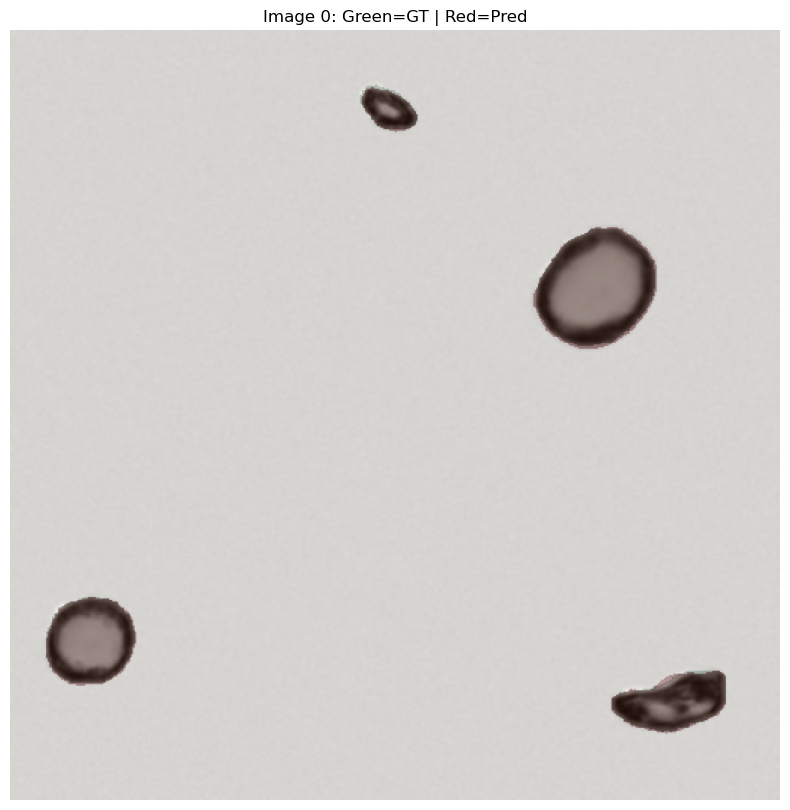

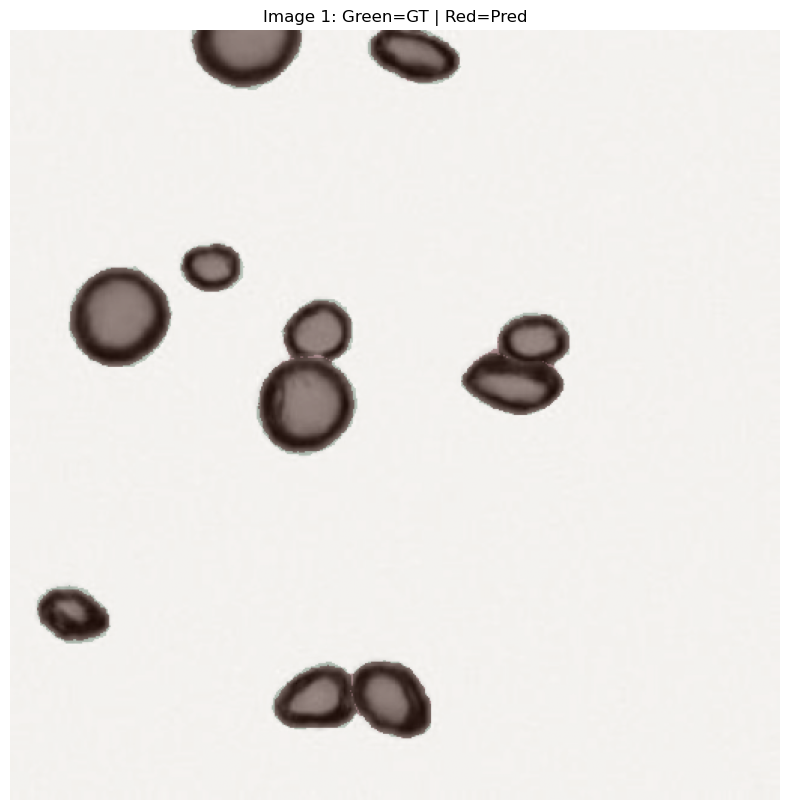

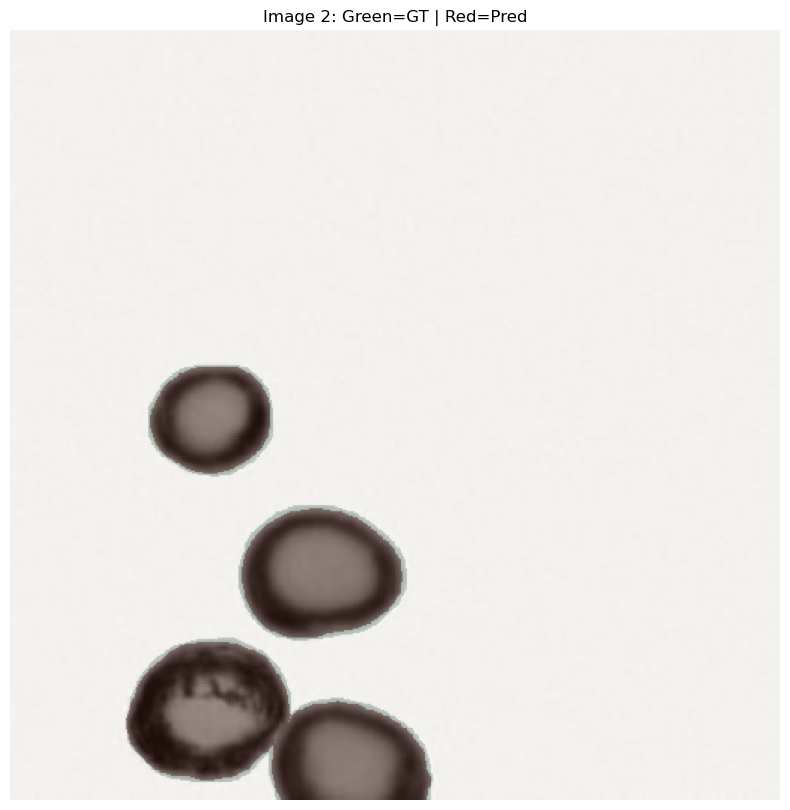

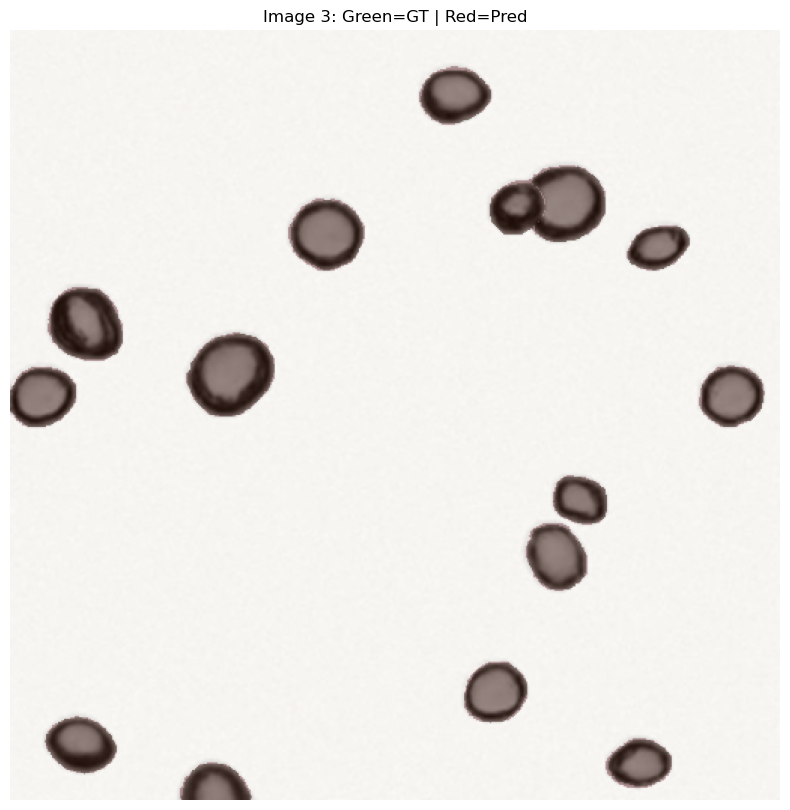

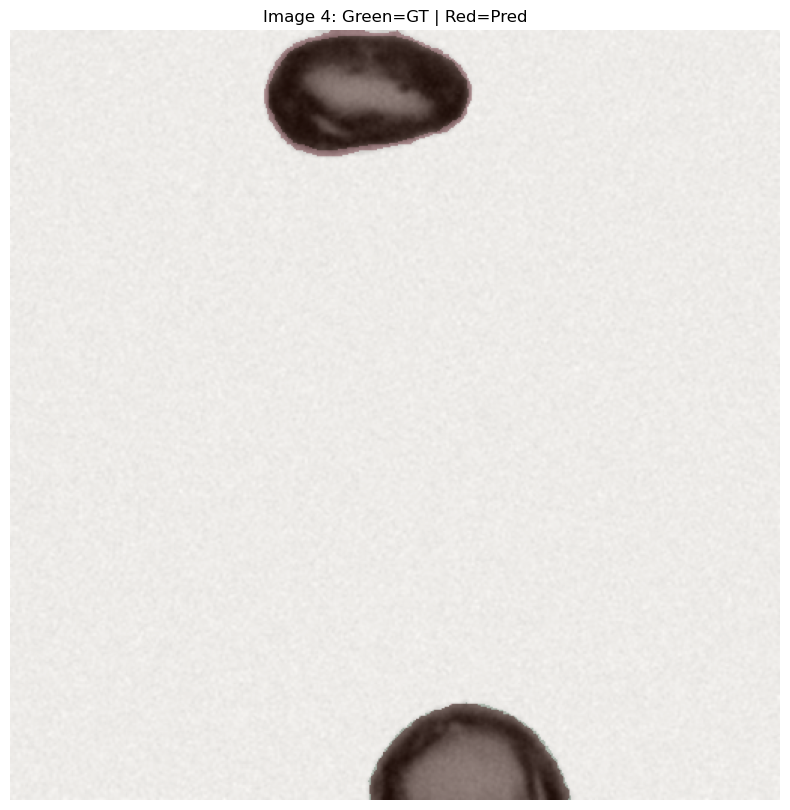


Final Evaluation Metrics:
Average Precision:         0.9643
Average Recall:            0.9666
Average F1-score:          0.9645
Average Dice Coefficient:  0.9645
Average IoU (Jaccard):     0.9315

--- Inference Timing Stats ---
Average inference time per image: 146.08 ms
Standard deviation:               19.40 ms
Maximum inference time:          160.60 ms
Estimated FPS:                    6.85


In [8]:
# For debug/visualization on first 5 test images
evaluate_unet_segmentation_metrics(model, data_loader_test, device=device, model_name=model_name, max_images=5, visualize=True)